In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import gzip
import matplotlib.pyplot as plt
import math
import matplotlib.font_manager as fm


from pems_utils import y_weighted_fill_or_smooth, find_congestion_blocks_merged, filter_congestion_blocks, plot_matrix, process_pems

font_path = "/Users/andrewmiller/Downloads/Latin_Modern-otf-2_006-12_08_2025/lmroman12-regular.otf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

print(prop.get_name())  # see the actual family name

plt.rcParams["font.family"] = prop.get_name()

data_dir = Path("../data/d12_feb_data_5_min")

cols = [
    "timestamp",
    "station_id",
    "district",
    "freeway",
    "direction_of_travel",
    "lane_type",
    "station_length",
    "samples",
    "percent_observed",
    "total_flow",
    "avg_occupancy",
    "avg_speed",
    "lane_1_samples",
    "lane_1_flow",
    "lane_1_avg_occupancy",
    "lane_1_avg_speed",
    "lane_1_observed",
    "lane_2_samples",
    "lane_2_flow",
    "lane_2_avg_occupancy",
    "lane_2_avg_speed",
    "lane_2_observed",    
    "lane_3_samples",
    "lane_3_flow",
    "lane_3_avg_occupancy",
    "lane_3_avg_speed",
    "lane_3_observed",
    "lane_4_samples",
    "lane_4_flow",
    "lane_4_avg_occupancy",
    "lane_4_avg_speed",
    "lane_4_observed",   
    "lane_5_samples",
    "lane_5_flow",
    "lane_5_avg_occupancy",
    "lane_5_avg_speed",
    "lane_5_observed",
    "lane_6_samples",
    "lane_6_flow",
    "lane_6_avg_occupancy",
    "lane_6_avg_speed",
    "lane_6_observed",
    "lane_7_samples",
    "lane_7_flow",
    "lane_7_avg_occupancy",
    "lane_7_avg_speed",
    "lane_7_observed",
    "lane_8_samples",
    "lane_8_flow",
    "lane_8_avg_occupancy",
    "lane_8_avg_speed",
    "lane_8_observed"
]

daily_dfs = {}

for p in sorted(data_dir.glob("*.txt.gz")):
    # detect delimiter from first line
    with gzip.open(p, "rt") as f:
        first = f.readline()
    sep = "\t" if first.count("\t") > first.count(",") else ","

    df = pd.read_csv(
        p,
        compression="gzip",
        sep=sep,
        header=None,      # key: file has no usable header row
        names=cols,       # force column names in this exact order
        low_memory=False,
    )

    daily_dfs[p.stem.replace(".txt", "")] = df

LMRoman12


In [3]:
# 1) combine all dfs from the dictionary
master_df = pd.concat(daily_dfs.values(), ignore_index=True)

freeway_direction_pairs = (
    master_df[["freeway", "direction_of_travel"]]
    .drop_duplicates()
    .sort_values(["freeway", "direction_of_travel"])
    .itertuples(index=False, name=None)
)
freeway_direction_pairs = list(freeway_direction_pairs)

In [4]:
freeway_direction_pairs

[(1, 'N'),
 (1, 'S'),
 (5, 'N'),
 (5, 'S'),
 (22, 'E'),
 (22, 'W'),
 (55, 'N'),
 (55, 'S'),
 (57, 'N'),
 (57, 'S'),
 (73, 'N'),
 (73, 'S'),
 (74, 'E'),
 (74, 'W'),
 (91, 'E'),
 (91, 'W'),
 (133, 'N'),
 (133, 'S'),
 (142, 'E'),
 (142, 'W'),
 (241, 'N'),
 (241, 'S'),
 (261, 'N'),
 (261, 'S'),
 (405, 'N'),
 (405, 'S'),
 (605, 'N'),
 (605, 'S')]

In [5]:
# Load station metadata
stations = pd.read_csv('../data/d12_feb_data_5_min/district12_stations.txt', sep="\t")
rename_map = {col: col.lower().replace(" ", "_") for col in stations.columns}
stations.rename(columns=rename_map, inplace=True)
stations.rename(columns={"id": "station_id"}, inplace=True)

In [6]:
# --- configurable ---
EXPECTED_ROWS_PER_STATION = 3037  # keep your original threshold logic
MIN_STATION_COVERAGE = 0.7

# freeway_direction_pairs assumed to be like [(5, "S"), (5, "N"), ...]
# stations assumed to have columns: station_id, fwy, dir, type, abs_pm, length

# 1) shared cleaning once
base_df = master_df.copy()
base_df["freeway"] = pd.to_numeric(base_df["freeway"], errors="coerce")
base_df["direction_of_travel"] = base_df["direction_of_travel"].astype(str).str.strip().str.upper()
base_df["timestamp"] = pd.to_datetime(base_df["timestamp"], errors="coerce")
base_df["lane_type"] = base_df["lane_type"].astype(str).str.strip().str.upper()

base_df = base_df[
    (base_df["timestamp"].dt.hour >= 6) &
    (base_df["timestamp"].dt.hour < 20) &
    (base_df["lane_type"].isin(["ML", "HV"]))
].copy()

processed_dfs = {}
station_counts_by_pair = {}

for fwy, direction in freeway_direction_pairs:
    direction = str(direction).strip().upper()

    # key name, e.g. i5_s
    key = f"{int(fwy)}_{direction.lower()}"

    # 2) pair filter
    df = base_df[
        (base_df["freeway"] == float(fwy)) &
        (base_df["direction_of_travel"] == direction)
    ].copy()

    if df.empty:
        processed_dfs[key] = df
        continue

    # 3) unit transforms / densities
    df["total_flow"] = pd.to_numeric(df["total_flow"], errors="coerce") * 20  # veh/hr

    for lane in range(1, 9):
        flow_col = f"lane_{lane}_flow"
        speed_col = f"lane_{lane}_avg_speed"
        density_col = f"lane_{lane}_density"

        if flow_col in df.columns and speed_col in df.columns:
            flow = pd.to_numeric(df[flow_col], errors="coerce")
            speed = pd.to_numeric(df[speed_col], errors="coerce").replace(0, np.nan)
            df[density_col] = (flow * 20) / speed  # veh/mi/lane

    density_cols = [f"lane_{lane}_density" for lane in range(1, 9) if f"lane_{lane}_density" in df.columns]
    df["avg_density"] = df[density_cols].mean(axis=1, skipna=True) if density_cols else np.nan

    # keep target columns if present
    keep_cols = ["timestamp", "station_id", "lane_type", "total_flow", "avg_speed", "samples", "percent_observed", "avg_density"]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    # 4) percent_observed filter
    df["percent_observed"] = pd.to_numeric(df["percent_observed"], errors="coerce")
    df = df[df["percent_observed"] != 0].copy()

    # 5) station coverage filter
    station_counts = (
        df.groupby("station_id")
          .size()
          .reset_index(name="row_count")
          .sort_values("row_count", ascending=False)
    )
    station_counts["percentage"] = station_counts["row_count"] / EXPECTED_ROWS_PER_STATION
    station_counts_by_pair[key] = station_counts

    high_pct_station_ids = station_counts.loc[station_counts["percentage"] > MIN_STATION_COVERAGE, "station_id"].tolist()
    df = df[df["station_id"].isin(high_pct_station_ids)].copy()

    # 6) stations merge for this freeway/direction + ML/HV
    st = stations.copy()
    st["dir"] = st["dir"].astype(str).str.strip().str.upper()
    st["type"] = st["type"].astype(str).str.strip().str.upper()
    st["fwy"] = pd.to_numeric(st["fwy"], errors="coerce")

    st = st[
        (st["fwy"] == float(fwy)) &
        (st["dir"] == direction) &
        (st["type"].isin(["ML", "HV"]))
    ].copy()

    # optional sanity check per pair
    print(f"\n{key} station length summary:")
    print(st["length"].describe())

    df = df.merge(st[["station_id", "abs_pm"]], on="station_id", how="left")

    processed_dfs[key] = df

# Example:
# processed_dfs["i5_s"].head()
# station_counts_by_pair["i5_s"].head()


1_n station length summary:
count    9.000000
mean     1.347778
std      0.962367
min      0.485000
25%      0.595000
50%      0.725000
75%      1.825000
max      2.840000
Name: length, dtype: float64

1_s station length summary:
count    9.000000
mean     1.362222
std      0.952284
min      0.530000
25%      0.600000
50%      0.725000
75%      1.825000
max      2.790000
Name: length, dtype: float64

5_n station length summary:
count    226.000000
mean       0.389823
std        0.216511
min        0.085000
25%        0.276250
50%        0.360000
75%        0.475000
max        2.665000
Name: length, dtype: float64

5_s station length summary:
count    220.000000
mean       0.400327
std        0.226783
min        0.079000
25%        0.277250
50%        0.397000
75%        0.475000
max        2.665000
Name: length, dtype: float64

22_e station length summary:
count    75.000000
mean      0.352667
std       0.213881
min       0.165000
25%       0.281000
50%       0.320000
75%       0.3700

In [7]:
processed_dfs

{'1_n': Empty DataFrame
 Columns: [timestamp, station_id, lane_type, total_flow, avg_speed, samples, percent_observed, avg_density, abs_pm]
 Index: [],
 '1_s': Empty DataFrame
 Columns: [timestamp, station_id, lane_type, total_flow, avg_speed, samples, percent_observed, avg_density, abs_pm]
 Index: [],
 '5_n':                  timestamp  station_id lane_type  total_flow  avg_speed  \
 0      2026-02-02 06:00:00     1204198        ML      4940.0       67.1   
 1      2026-02-02 06:00:00     1204211        ML      4040.0       68.5   
 2      2026-02-02 06:00:00     1204230        ML      4280.0       70.9   
 3      2026-02-02 06:00:00     1204244        ML      4260.0       66.3   
 4      2026-02-02 06:00:00     1204255        ML      4960.0       66.0   
 ...                    ...         ...       ...         ...        ...   
 538827 2026-02-27 19:55:00     1221067        HV      1240.0       64.4   
 538828 2026-02-27 19:55:00     1221197        HV      1840.0       64.5   
 5388

In [20]:
# Assumes:
# - processed_dfs: dict like {"i5_s": df, "i80_e": df, ...}
# - process_pems(...)
# - y_weighted_fill_or_smooth(...)

time_increment_seconds = pd.Timedelta(seconds=5 * 60)
time_col = "timestamp"
postmile_col = "abs_pm"
SPACE_STEP_MI = 0.4

all_corridor_results = {}

for corridor_key, corridor_df in processed_dfs.items():
    if corridor_df.empty:
        print(f"[skip] {corridor_key}: empty df")
        continue

    df = corridor_df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col, postmile_col]).copy()

    if df.empty:
        print(f"[skip] {corridor_key}: no valid timestamp/postmile rows")
        continue

    start_pm = df[postmile_col].max()
    end_pm = df[postmile_col].min()
    t_min = (df[time_col] - df[time_col].dt.normalize()).min()
    t_max = (df[time_col] - df[time_col].dt.normalize()).max()

    expected_time_bins = (t_max - t_min) / time_increment_seconds
    expected_space_bins = (max(start_pm, end_pm) - min(start_pm, end_pm)) / SPACE_STEP_MI
    print(f"\n[{corridor_key}] t_min={t_min}, t_max={t_max}, "
          f"expected_time_bins={expected_time_bins}, expected_space_bins={expected_space_bins}")

    # 1) Daily gridding
    daily_density_results = {}
    for day in sorted(df[time_col].dt.date.unique()):
        day_df = df[df[time_col].dt.date == day].copy()
        ref_date = pd.Timestamp(day_df[time_col].min().date())
        t_min_dated = ref_date + t_min
        t_max_dated = ref_date + t_max

        density_matrix, density_df = process_pems(
            day_df,
            time_col=time_col,
            postmile_col=postmile_col,
            value_col="avg_density",
            start_pm=start_pm,
            end_pm=end_pm,
            time_interval=time_increment_seconds,
            space_interval=SPACE_STEP_MI,
            t_min=t_min_dated,
            t_max=t_max_dated,
        )

        daily_density_results[str(day)] = {
            "density_matrix": density_matrix,
            "density_df": density_df,
        }

    # 2) Impute each daily matrix
    imputed_daily_density_results = {}
    for day, result in daily_density_results.items():
        m = np.asarray(result["density_matrix"], dtype=float)
        imputed_m = y_weighted_fill_or_smooth(m, mode="smooth", num_neighbors=2, max_passes=5)

        imputed_daily_density_results[day] = {
            **result,
            "imputed_density_matrix": imputed_m,
        }

        print(f"[{corridor_key}] {day} NaNs before={np.isnan(m).sum()} after={np.isnan(imputed_m).sum()}")

    # 3) Rolling prior mean/std over imputed matrices
    days = sorted(imputed_daily_density_results.keys())
    if not days:
        print(f"[skip] {corridor_key}: no daily matrices after gridding")
        continue

    first_mat = np.asarray(imputed_daily_density_results[days[0]]["imputed_density_matrix"], dtype=float)
    shape = first_mat.shape

    rolling_density_stats = {}
    prior_stack = []

    for day in days:
        current = np.asarray(imputed_daily_density_results[day]["imputed_density_matrix"], dtype=float)

        if len(prior_stack) == 0:
            prior_mean = np.full(shape, np.nan)
            prior_std = np.full(shape, np.nan)
        else:
            stack = np.stack(prior_stack, axis=0)
            prior_mean = np.nanmean(stack, axis=0)
            prior_std = np.nanstd(stack, axis=0)

        rolling_density_stats[day] = {
            "prior_mean_matrix": prior_mean,
            "prior_std_matrix": prior_std,
        }

        prior_stack.append(current)

    # 4) Final summaries for this corridor
    last_day = days[-1]
    final_mean_matrix = rolling_density_stats[last_day]["prior_mean_matrix"]
    final_std_matrix = rolling_density_stats[last_day]["prior_std_matrix"]

    avg_std_all_cells = np.nanmean(final_std_matrix)
    valid_mask = ~np.isnan(final_mean_matrix)
    pct_above_35 = (
        (np.sum(final_mean_matrix[valid_mask] > 35) / np.sum(valid_mask)) * 100
        if np.sum(valid_mask) > 0 else np.nan
    )

    final_mean_matrix_smoothed = y_weighted_fill_or_smooth(
        final_mean_matrix, mode="smooth", num_neighbors=2, max_passes=1
    )

    print(f"[{corridor_key}] Avg std={avg_std_all_cells:.4f}, "
          f"% cells >35={pct_above_35:.2f}%")

    all_corridor_results[corridor_key] = {
        "meta": {
            "start_pm": start_pm,
            "end_pm": end_pm,
            "t_min": t_min,
            "t_max": t_max,
            "expected_time_bins": expected_time_bins,
            "expected_space_bins": expected_space_bins,
        },
        "daily_density_results": daily_density_results,
        "imputed_daily_density_results": imputed_daily_density_results,
        "rolling_density_stats": rolling_density_stats,
        "final_mean_matrix": final_mean_matrix,
        "final_std_matrix": final_std_matrix,
        "final_mean_matrix_smoothed": final_mean_matrix_smoothed,
        "summary": {
            "avg_std_all_cells": avg_std_all_cells,
            "pct_cells_above_35": pct_above_35,
            "last_day": last_day,
        },
    }

# Example access:
# all_corridor_results["i5_s"]["summary"]
# all_corridor_results["i5_s"]["daily_density_results"]["2026-02-03"]["density_matrix"]


[skip] 1_n: empty df
[skip] 1_s: empty df

[5_n] t_min=0 days 06:00:00, t_max=0 days 19:55:00, expected_time_bins=167.0, expected_space_bins=109.23249999999999
[5_n] 2026-02-02 NaNs before=8731 after=5844
[5_n] 2026-02-03 NaNs before=14698 after=7150
[5_n] 2026-02-04 NaNs before=13600 after=3772
[5_n] 2026-02-05 NaNs before=4175 after=0
[5_n] 2026-02-06 NaNs before=4175 after=0
[5_n] 2026-02-09 NaNs before=4175 after=0
[5_n] 2026-02-10 NaNs before=4175 after=0
[5_n] 2026-02-11 NaNs before=4175 after=0
[5_n] 2026-02-12 NaNs before=4175 after=0
[5_n] 2026-02-13 NaNs before=4175 after=0
[5_n] 2026-02-17 NaNs before=4175 after=0
[5_n] 2026-02-18 NaNs before=4175 after=0
[5_n] 2026-02-19 NaNs before=4175 after=0
[5_n] 2026-02-20 NaNs before=4175 after=0
[5_n] 2026-02-23 NaNs before=5010 after=0
[5_n] 2026-02-24 NaNs before=5845 after=0
[5_n] 2026-02-25 NaNs before=5171 after=220
[5_n] 2026-02-26 NaNs before=5177 after=0
[5_n] 2026-02-27 NaNs before=5177 after=0


/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/ipykernel_29914/2555824545.py:95: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(stack, axis=0)
/opt/anaconda3/envs/metanet_geo/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[5_n] Avg std=4.8423, % cells >35=27.94%

[5_s] t_min=0 days 06:00:00, t_max=0 days 19:55:00, expected_time_bins=167.0, expected_space_bins=108.88250000000002
[5_s] 2026-02-02 NaNs before=8794 after=5791
[5_s] 2026-02-03 NaNs before=14735 after=7391
[5_s] 2026-02-04 NaNs before=13698 after=4134
[5_s] 2026-02-05 NaNs before=4008 after=0
[5_s] 2026-02-06 NaNs before=4008 after=0
[5_s] 2026-02-09 NaNs before=4342 after=0
[5_s] 2026-02-10 NaNs before=4008 after=0
[5_s] 2026-02-11 NaNs before=4008 after=0
[5_s] 2026-02-12 NaNs before=4008 after=0
[5_s] 2026-02-13 NaNs before=4008 after=0
[5_s] 2026-02-17 NaNs before=4008 after=0
[5_s] 2026-02-18 NaNs before=4009 after=0
[5_s] 2026-02-19 NaNs before=4175 after=0
[5_s] 2026-02-20 NaNs before=4010 after=0
[5_s] 2026-02-23 NaNs before=4843 after=0
[5_s] 2026-02-24 NaNs before=5678 after=0
[5_s] 2026-02-25 NaNs before=5168 after=218
[5_s] 2026-02-26 NaNs before=5345 after=0
[5_s] 2026-02-27 NaNs before=5344 after=0
[5_s] Avg std=4.7161, % cells 

/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/ipykernel_29914/2555824545.py:95: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(stack, axis=0)
/opt/anaconda3/envs/metanet_geo/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



[22_e] t_min=0 days 06:00:00, t_max=0 days 19:55:00, expected_time_bins=167.0, expected_space_bins=31.484999999999996
[22_e] 2026-02-02 NaNs before=2067 after=1728
[22_e] 2026-02-03 NaNs before=2386 after=2080
[22_e] 2026-02-04 NaNs before=1502 after=1088
[22_e] 2026-02-05 NaNs before=501 after=0
[22_e] 2026-02-06 NaNs before=501 after=0
[22_e] 2026-02-09 NaNs before=501 after=0
[22_e] 2026-02-10 NaNs before=503 after=0
[22_e] 2026-02-11 NaNs before=501 after=0
[22_e] 2026-02-12 NaNs before=501 after=0
[22_e] 2026-02-13 NaNs before=501 after=0
[22_e] 2026-02-17 NaNs before=501 after=0
[22_e] 2026-02-18 NaNs before=501 after=0
[22_e] 2026-02-19 NaNs before=501 after=0
[22_e] 2026-02-20 NaNs before=501 after=0
[22_e] 2026-02-23 NaNs before=668 after=0
[22_e] 2026-02-24 NaNs before=1002 after=0
[22_e] 2026-02-25 NaNs before=1054 after=64
[22_e] 2026-02-26 NaNs before=1002 after=0
[22_e] 2026-02-27 NaNs before=1002 after=0
[22_e] Avg std=5.0529, % cells >35=39.88%

[22_w] t_min=0 days 06:

...

/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/ipykernel_29914/2555824545.py:95: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(stack, axis=0)
/opt/anaconda3/envs/metanet_geo/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[605_n] 2026-02-02 NaNs before=275 after=162
[605_n] 2026-02-03 NaNs before=297 after=195
[605_n] 2026-02-04 NaNs before=237 after=105
[605_n] 2026-02-05 NaNs before=167 after=0
[605_n] 2026-02-06 NaNs before=167 after=0
[605_n] 2026-02-09 NaNs before=167 after=0
[605_n] 2026-02-10 NaNs before=167 after=0
[605_n] 2026-02-11 NaNs before=167 after=0
[605_n] 2026-02-12 NaNs before=167 after=0
[605_n] 2026-02-13 NaNs before=167 after=0
[605_n] 2026-02-17 NaNs before=167 after=0
[605_n] 2026-02-18 NaNs before=167 after=0
[605_n] 2026-02-19 NaNs before=167 after=0
[605_n] 2026-02-20 NaNs before=167 after=0
[605_n] 2026-02-23 NaNs before=167 after=0
[605_n] 2026-02-24 NaNs before=167 after=0
[605_n] 2026-02-25 NaNs before=171 after=6
[605_n] 2026-02-26 NaNs before=167 after=0
[605_n] 2026-02-27 NaNs before=167 after=0
[605_n] Avg std=3.7660, % cells >35=5.39%

[605_s] t_min=0 days 06:00:00, t_max=0 days 19:55:00, expected_time_bins=167.0, expected_space_bins=2.5249999999999995


/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/ipykernel_29914/2555824545.py:95: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(stack, axis=0)
/opt/anaconda3/envs/metanet_geo/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[605_s] 2026-02-02 NaNs before=275 after=162
[605_s] 2026-02-03 NaNs before=297 after=195
[605_s] 2026-02-04 NaNs before=237 after=105
[605_s] 2026-02-05 NaNs before=167 after=0
[605_s] 2026-02-06 NaNs before=167 after=0
[605_s] 2026-02-09 NaNs before=167 after=0
[605_s] 2026-02-10 NaNs before=167 after=0
[605_s] 2026-02-11 NaNs before=167 after=0
[605_s] 2026-02-12 NaNs before=167 after=0
[605_s] 2026-02-13 NaNs before=167 after=0
[605_s] 2026-02-17 NaNs before=167 after=0
[605_s] 2026-02-18 NaNs before=167 after=0
[605_s] 2026-02-19 NaNs before=167 after=0
[605_s] 2026-02-20 NaNs before=167 after=0
[605_s] 2026-02-23 NaNs before=167 after=0
[605_s] 2026-02-24 NaNs before=167 after=0
[605_s] 2026-02-25 NaNs before=171 after=6
[605_s] 2026-02-26 NaNs before=167 after=0
[605_s] 2026-02-27 NaNs before=167 after=0
[605_s] Avg std=8.8746, % cells >35=15.57%


/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/ipykernel_29914/2555824545.py:95: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(stack, axis=0)
/opt/anaconda3/envs/metanet_geo/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


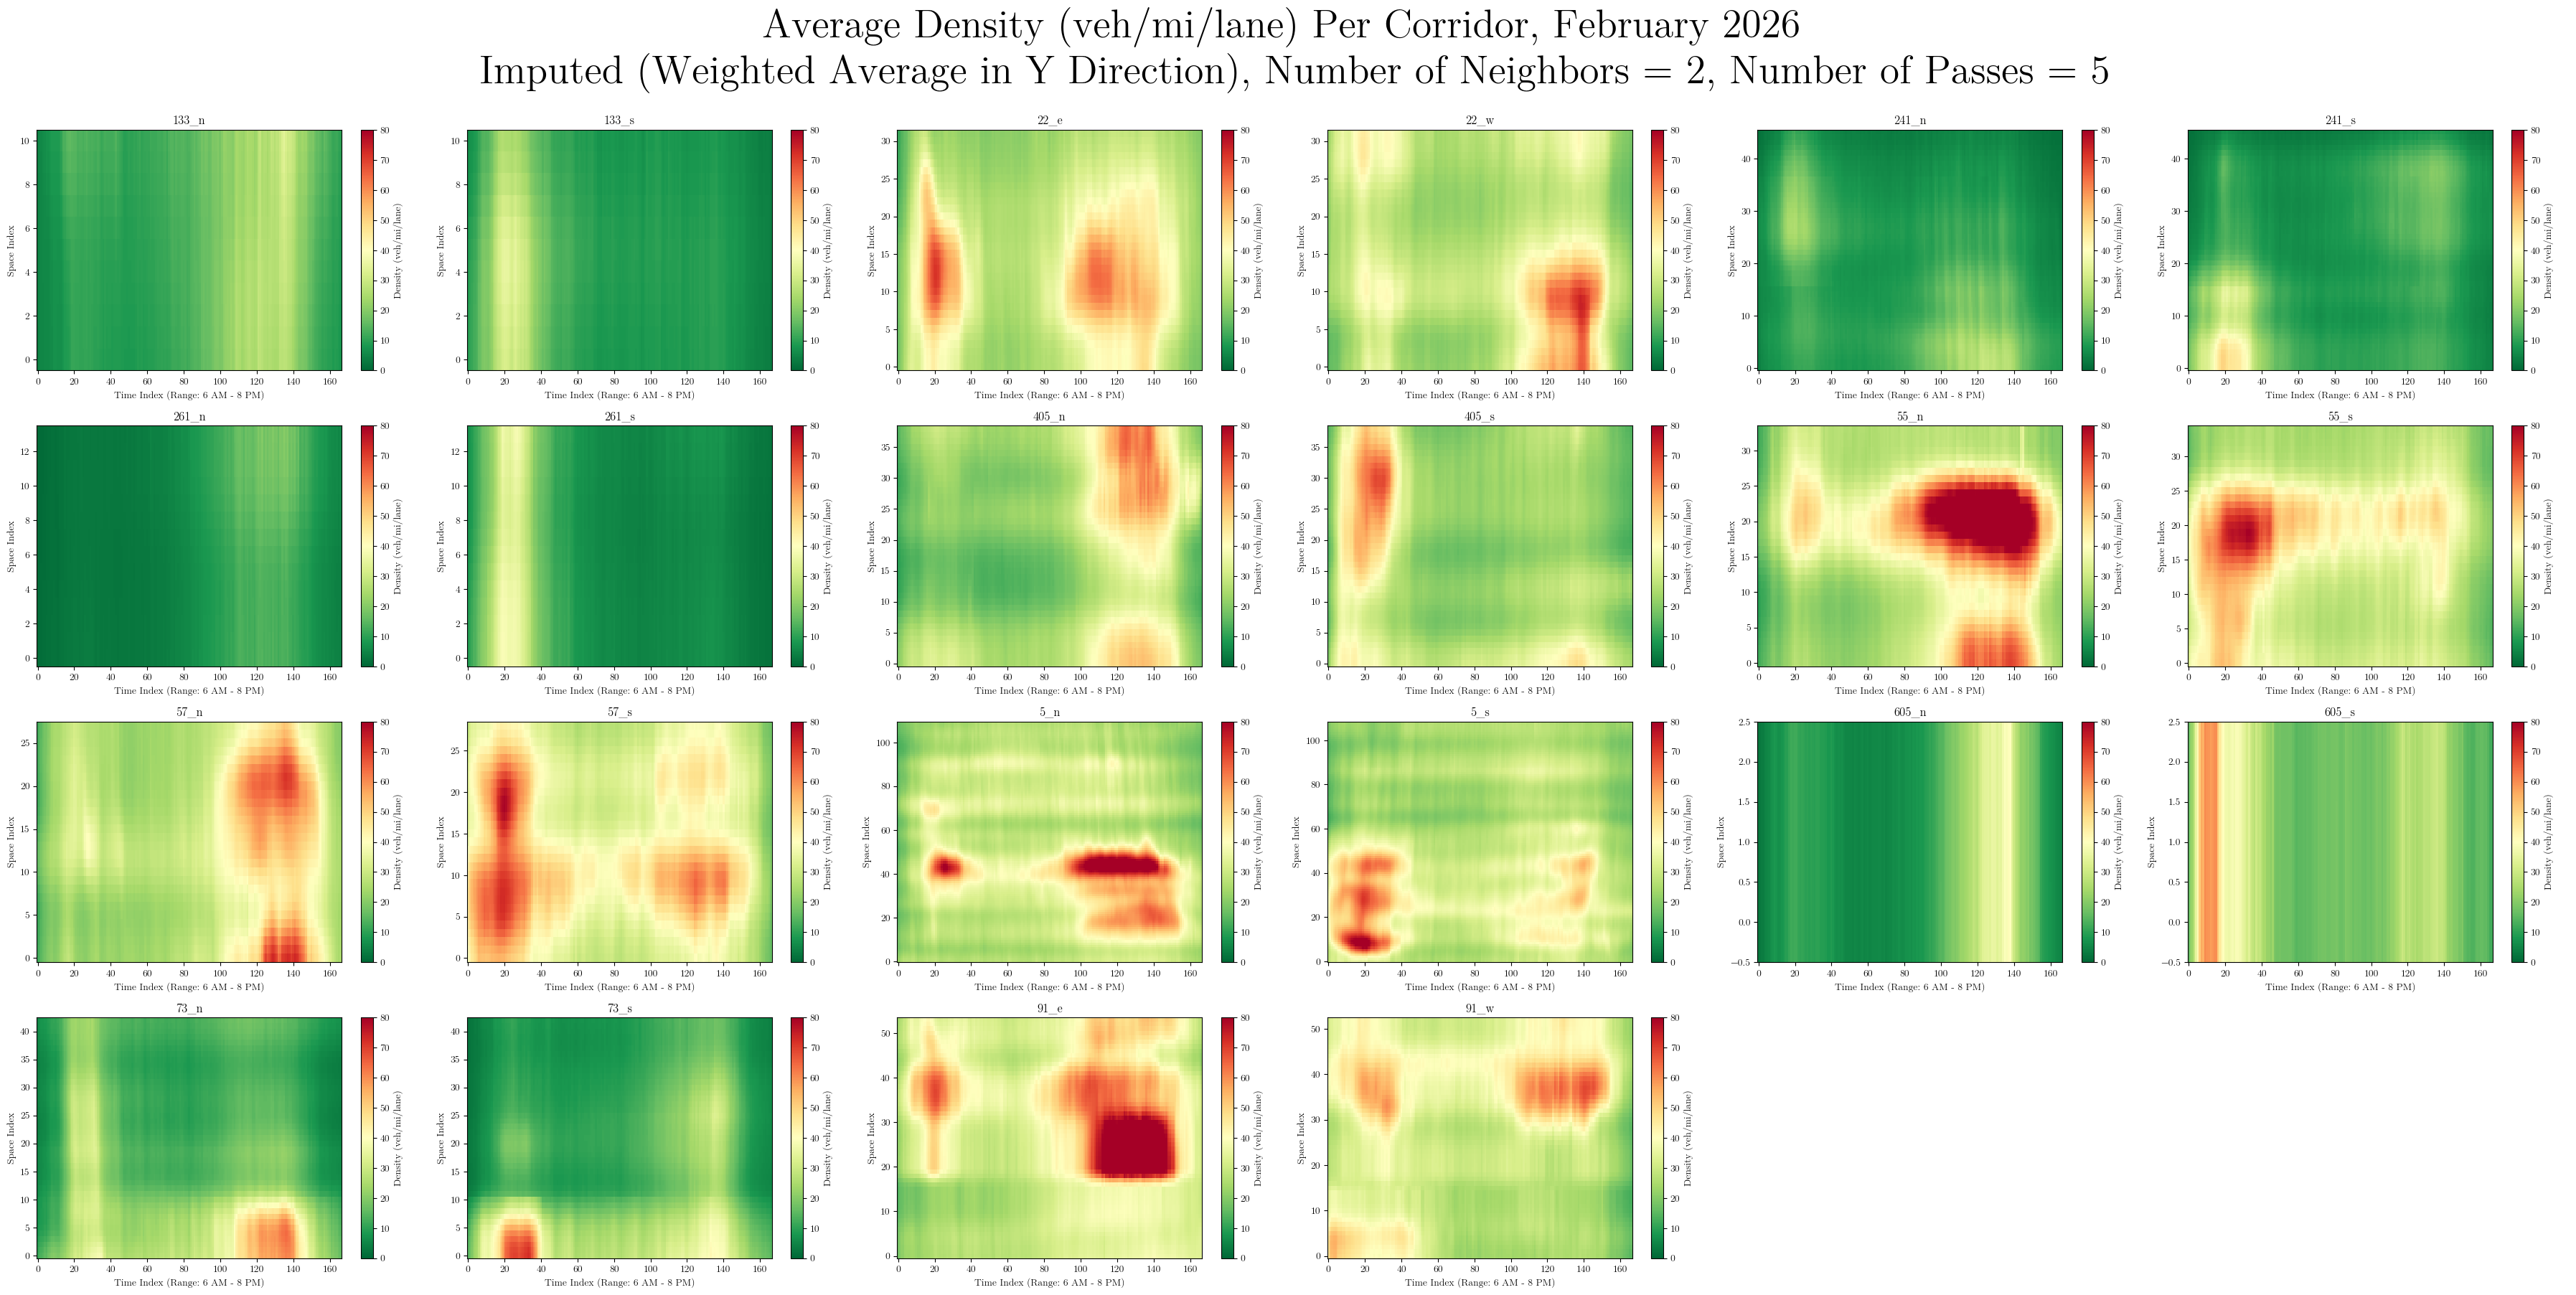

In [21]:
# all_corridor_results expected from previous step
import math

corridors = sorted(all_corridor_results.keys())
n = len(corridors)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

for idx, corridor in enumerate(corridors):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    mat = np.asarray(all_corridor_results[corridor]["final_mean_matrix"], dtype=float)

    im = ax.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
        vmin=0,
        vmax=80,
        cmap="RdYlGn_r",
    )
    ax.set_title(corridor)
    ax.set_xlabel("Time Index (Range: 6 AM - 8 PM)")
    ax.set_ylabel("Space Index")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Density (veh/mi/lane)")

# hide unused subplots
for idx in range(n, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis("off")

fig.suptitle("Average Density (veh/mi/lane) Per Corridor, February 2026 \n Imputed (Weighted Average in Y Direction), Number of Neighbors = 2, Number of Passes = 5", y=1, fontsize=40)
fig.tight_layout()
plt.show()

In [14]:
# user-defined corridors to exclude
exclude_corridors = {
    "91_w",
    "91_e",
}

advancing_corridors = sorted(
    [k for k in all_corridor_results.keys() if k not in exclude_corridors]
)

In [15]:
congested_blocks = {}

for corridor_key in advancing_corridors:
    if corridor_key not in all_corridor_results:
        print(f"[skip] {corridor_key}: not found in all_corridor_results")
        continue

    final_mean_matrix_smoothed = all_corridor_results[corridor_key].get("final_mean_matrix_smoothed")
    if final_mean_matrix_smoothed is None:
        print(f"[skip] {corridor_key}: missing final_mean_matrix_smoothed")
        continue

    # 1) find merged congestion blocks
    blocks = find_congestion_blocks_merged(
        final_mean_matrix_smoothed,
        threshold=35,
        connectivity=4
    )

    print(f"\n[{corridor_key}] Found {len(blocks)} congestion block(s)")
    for i, b in enumerate(blocks, 1):
        print(
            f"[{corridor_key}] Block {i}: rows {b['row_min']}-{b['row_max']}, "
            f"cols {b['col_min']}-{b['col_max']}, n_cells={b['n_cells']}"
        )

    # 2) filter blocks
    filtered_blocks = filter_congestion_blocks(
        blocks,
        min_width_cols=6,
        min_height_rows=2
    )

    print(f"[{corridor_key}] After filtering: {len(filtered_blocks)} block(s)")
    for i, b in enumerate(filtered_blocks, 1):
        print(
            f"[{corridor_key}] Filtered Block {i}: rows {b['row_min']}-{b['row_max']}, "
            f"cols {b['col_min']}-{b['col_max']}, n_cells={b['n_cells']}"
        )

    # 3) save outputs
    congested_blocks[corridor_key] = {
        "all_blocks": blocks,
        "filtered_blocks": filtered_blocks,
    }



[133_n] Found 1 congestion block(s)
[133_n] Block 1: rows 9-10, cols 134-136, n_cells=4
[133_n] After filtering: 0 block(s)

[133_s] Found 1 congestion block(s)
[133_s] Block 1: rows 3-7, cols 17-28, n_cells=44
[133_s] After filtering: 1 block(s)
[133_s] Filtered Block 1: rows 3-7, cols 17-28, n_cells=44

[22_e] Found 2 congestion block(s)
[22_e] Block 1: rows 0-28, cols 7-41, n_cells=623
[22_e] Block 2: rows 0-27, cols 80-154, n_cells=1446
[22_e] After filtering: 2 block(s)
[22_e] Filtered Block 1: rows 0-28, cols 7-41, n_cells=623
[22_e] Filtered Block 2: rows 0-27, cols 80-154, n_cells=1446

[22_w] Found 10 congestion block(s)
[22_w] Block 1: rows 0-2, cols 19-34, n_cells=34
[22_w] Block 2: rows 0-18, cols 91-154, n_cells=891
[22_w] Block 3: rows 7-16, cols 13-46, n_cells=190
[22_w] Block 4: rows 9-9, cols 53-56, n_cells=4
[22_w] Block 5: rows 9-9, cols 61-70, n_cells=10
[22_w] Block 6: rows 23-31, cols 3-44, n_cells=204
[22_w] Block 7: rows 26-31, cols 124-151, n_cells=120
[22_w] 

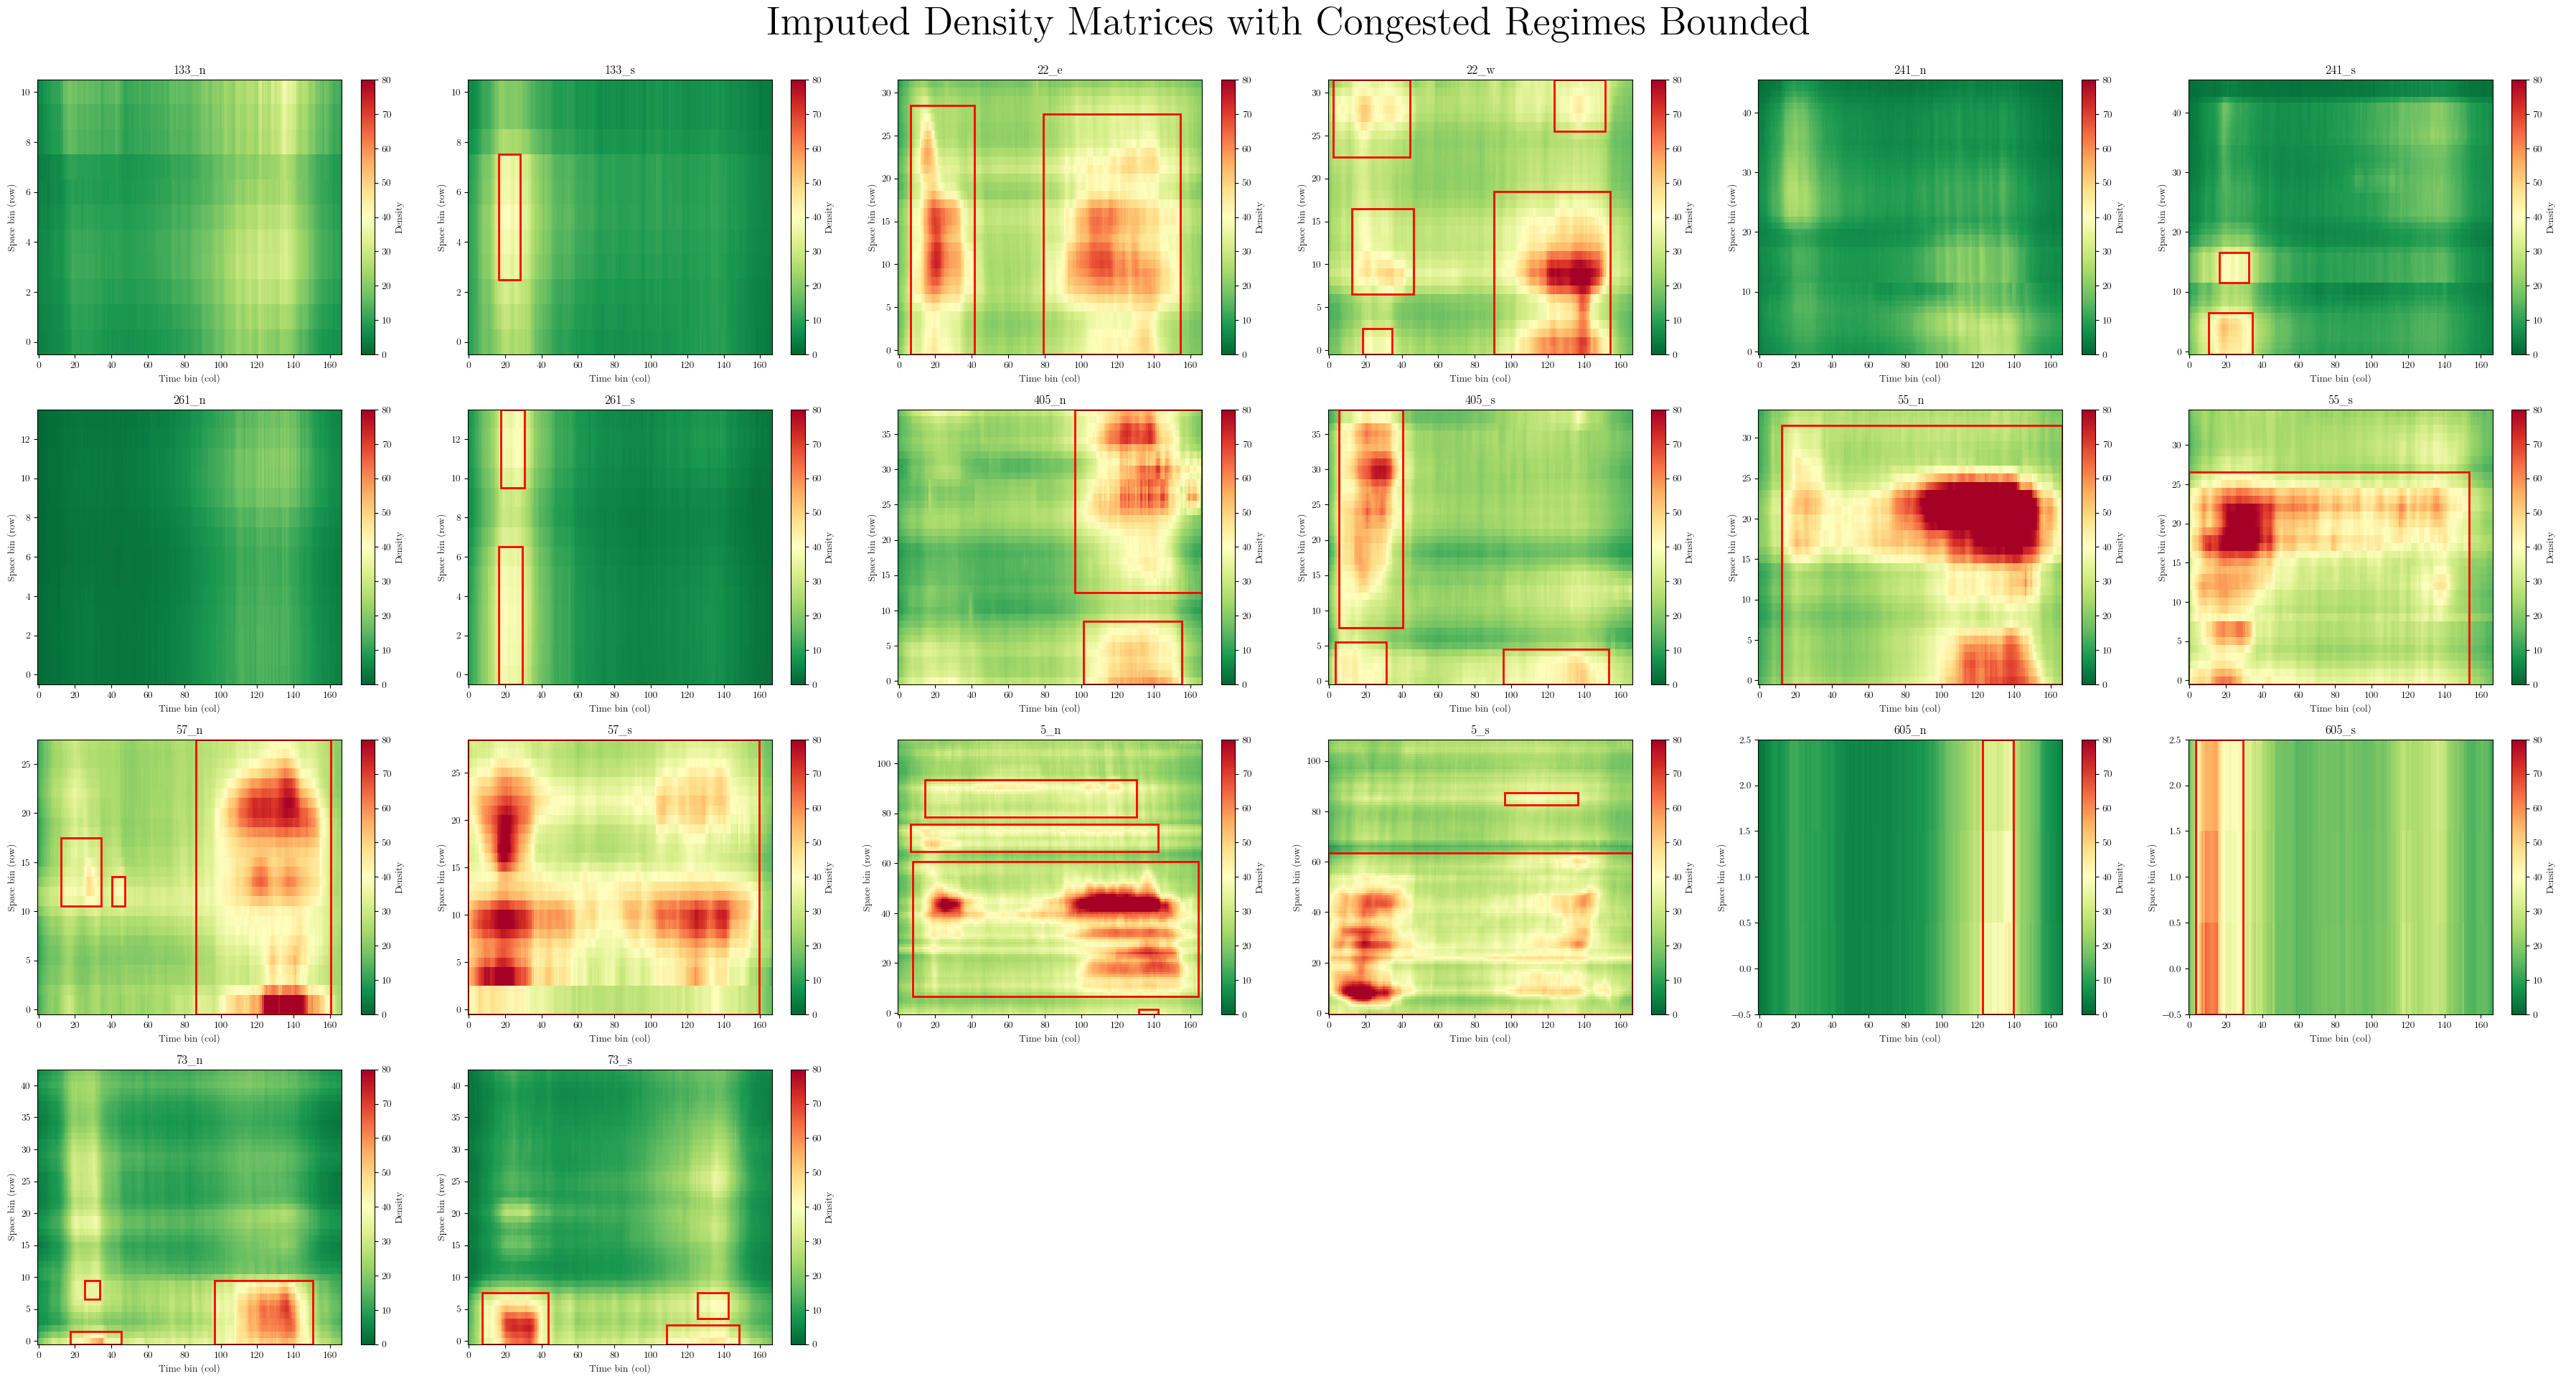

In [20]:
from matplotlib.patches import Rectangle

corridors = [k for k in advancing_corridors if k in all_corridor_results]
n = len(corridors)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows), squeeze=False)

for idx, corridor_key in enumerate(corridors):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    mat = np.asarray(all_corridor_results[corridor_key]["final_mean_matrix_smoothed"], dtype=float)

    im = ax.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
        vmin=0,
        vmax=80,
        cmap="RdYlGn_r",
    )
    ax.set_title(corridor_key)
    ax.set_xlabel("Time bin (col)")
    ax.set_ylabel("Space bin (row)")

    # Draw red boxes from congestion block output
    blocks = congested_blocks.get(corridor_key, {}).get("filtered_blocks", [])
    for b in blocks:
        row_min, row_max = b["row_min"], b["row_max"]
        col_min, col_max = b["col_min"], b["col_max"]

        # +1 because bounds are inclusive indices
        width = col_max - col_min + 1
        height = row_max - row_min + 1

        rect = Rectangle(
            (col_min - 0.5, row_min - 0.5),
            width,
            height,
            fill=False,
            edgecolor="red",
            linewidth=2.0,
        )
        ax.add_patch(rect)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Density")

# hide unused axes
for idx in range(n, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis("off")

fig.suptitle("Imputed Density Matrices with Congested Regimes Bounded", y=1, fontsize=40)
fig.tight_layout()
plt.show()

In [21]:
# --- constraints ---
THRESHOLD = 35
CONNECTIVITY = 4
MIN_WIDTH_COLS = 6
MIN_HEIGHT_ROWS = 2
MAX_HEIGHT_ROWS = 10   # space bins (rows)
MAX_WIDTH_COLS = 20    # time bins (cols)

def _block_size(b):
    h = b["row_max"] - b["row_min"] + 1
    w = b["col_max"] - b["col_min"] + 1
    return h, w

def _chunk_block_to_max(matrix, block, threshold=35, connectivity=4,
                        max_height_rows=10, max_width_cols=20):
    """
    Split one block into <= max_height_rows x <= max_width_cols tiles.
    Within each tile, re-find connected congested regions so we keep
    congested cells and avoid oversized bounding boxes.
    """
    h, w = _block_size(block)
    if h <= max_height_rows and w <= max_width_cols:
        return [dict(block)]

    rmin, rmax = block["row_min"], block["row_max"]
    cmin, cmax = block["col_min"], block["col_max"]

    chunked = []
    for r0 in range(rmin, rmax + 1, max_height_rows):
        r1 = min(r0 + max_height_rows - 1, rmax)
        for c0 in range(cmin, cmax + 1, max_width_cols):
            c1 = min(c0 + max_width_cols - 1, cmax)

            sub = np.asarray(matrix[r0:r1 + 1, c0:c1 + 1], dtype=float)

            # find congested components in this tile only
            sub_blocks = find_congestion_blocks_merged(
                sub, threshold=threshold, connectivity=connectivity, merge_touching=True
            )

            # map tile-local indices back to global indices
            for sb in sub_blocks:
                gb = {
                    "row_min": sb["row_min"] + r0,
                    "row_max": sb["row_max"] + r0,
                    "col_min": sb["col_min"] + c0,
                    "col_max": sb["col_max"] + c0,
                    "n_cells": sb["n_cells"],
                }
                gb["corners"] = {
                    "top_left": (gb["row_min"], gb["col_min"]),
                    "top_right": (gb["row_min"], gb["col_max"]),
                    "bottom_left": (gb["row_max"], gb["col_min"]),
                    "bottom_right": (gb["row_max"], gb["col_max"]),
                }
                chunked.append(gb)

    return chunked


congested_blocks = {}

for corridor_key in advancing_corridors:
    if corridor_key not in all_corridor_results:
        print(f"[skip] {corridor_key}: not found in all_corridor_results")
        continue

    mat = all_corridor_results[corridor_key].get("final_mean_matrix_smoothed")
    if mat is None:
        print(f"[skip] {corridor_key}: missing final_mean_matrix_smoothed")
        continue

    # 1) initial merged congestion regions
    raw_blocks = find_congestion_blocks_merged(
        mat, threshold=THRESHOLD, connectivity=CONNECTIVITY, merge_touching=True
    )

    # 2) split oversized regions into bounded chunks
    bounded_blocks = []
    for b in raw_blocks:
        bounded_blocks.extend(
            _chunk_block_to_max(
                mat, b,
                threshold=THRESHOLD,
                connectivity=CONNECTIVITY,
                max_height_rows=MAX_HEIGHT_ROWS,
                max_width_cols=MAX_WIDTH_COLS
            )
        )

    # 3) enforce min and max size filters
    final_blocks = []
    for b in bounded_blocks:
        h, w = _block_size(b)
        if (
            h >= MIN_HEIGHT_ROWS and
            w >= MIN_WIDTH_COLS and
            h <= MAX_HEIGHT_ROWS and
            w <= MAX_WIDTH_COLS
        ):
            b2 = dict(b)
            b2["height_rows"] = h
            b2["width_cols"] = w
            final_blocks.append(b2)

    congested_blocks[corridor_key] = {
        "raw_blocks": raw_blocks,
        "bounded_blocks": bounded_blocks,
        "filtered_blocks": final_blocks,
    }

    print(
        f"\n[{corridor_key}] raw={len(raw_blocks)} | "
        f"bounded={len(bounded_blocks)} | final={len(final_blocks)}"
    )
    for i, b in enumerate(final_blocks, 1):
        print(
            f"[{corridor_key}] Block {i}: rows {b['row_min']}-{b['row_max']} "
            f"(h={b['height_rows']}), cols {b['col_min']}-{b['col_max']} "
            f"(w={b['width_cols']}), n_cells={b['n_cells']}"
        )



[133_n] raw=1 | bounded=1 | final=0

[133_s] raw=1 | bounded=1 | final=1
[133_s] Block 1: rows 3-7 (h=5), cols 17-28 (w=12), n_cells=44

[22_e] raw=2 | bounded=17 | final=17
[22_e] Block 1: rows 0-9 (h=10), cols 7-26 (w=20), n_cells=162
[22_e] Block 2: rows 0-9 (h=10), cols 27-41 (w=15), n_cells=84
[22_e] Block 3: rows 10-19 (h=10), cols 7-26 (w=20), n_cells=184
[22_e] Block 4: rows 10-19 (h=10), cols 27-41 (w=15), n_cells=106
[22_e] Block 5: rows 20-28 (h=9), cols 9-23 (w=15), n_cells=87
[22_e] Block 6: rows 5-9 (h=5), cols 80-99 (w=20), n_cells=79
[22_e] Block 7: rows 0-9 (h=10), cols 100-119 (w=20), n_cells=185
[22_e] Block 8: rows 0-9 (h=10), cols 120-139 (w=20), n_cells=200
[22_e] Block 9: rows 0-9 (h=10), cols 140-154 (w=15), n_cells=82
[22_e] Block 10: rows 10-19 (h=10), cols 81-99 (w=19), n_cells=103
[22_e] Block 11: rows 10-19 (h=10), cols 100-119 (w=20), n_cells=200
[22_e] Block 12: rows 10-19 (h=10), cols 120-139 (w=20), n_cells=200
[22_e] Block 13: rows 10-19 (h=10), cols 

In [22]:
total_final_blocks = sum(
    len(v.get("filtered_blocks", []))
    for v in congested_blocks.values()
)

print(f"Total final blocks across all corridors: {total_final_blocks}")

Total final blocks across all corridors: 252


In [13]:
corridors = [k for k in advancing_corridors if k in all_corridor_results]
n = len(corridors)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows), squeeze=False)

for idx, corridor_key in enumerate(corridors):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    mat = np.asarray(all_corridor_results[corridor_key]["final_mean_matrix_smoothed"], dtype=float)

    im = ax.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
        vmin=0,
        vmax=80,
        cmap="RdYlGn_r",
    )
    ax.set_title(corridor_key)
    ax.set_xlabel("Time bin (col)")
    ax.set_ylabel("Space bin (row)")

    # Draw red boxes from congestion block output
    blocks = congested_blocks.get(corridor_key, {}).get("filtered_blocks", [])
    for b in blocks:
        row_min, row_max = b["row_min"], b["row_max"]
        col_min, col_max = b["col_min"], b["col_max"]

        # +1 because bounds are inclusive indices
        width = col_max - col_min + 1
        height = row_max - row_min + 1

        rect = Rectangle(
            (col_min - 0.5, row_min - 0.5),
            width,
            height,
            fill=False,
            edgecolor="red",
            linewidth=2.0,
        )
        ax.add_patch(rect)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Density")

# hide unused axes
for idx in range(n, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis("off")

fig.suptitle("Imputed Density Matrices with Congested Regimes Bounded -- Max Block Size Imposed", y=1, fontsize=40)
fig.tight_layout()
plt.show()

NameError: name 'advancing_corridors' is not defined